# Lab: Exploratory Decision Trees — Breast Cancer Wisconsin Dataset (Student Worksheet)

**Objective:** Build intuition for how a Decision Tree Classifier actually behaves —
not just how to call `.fit()`. You will explore split criteria (Gini vs Entropy),
tree depth, and other hyperparameters to find the configuration that generalizes best.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 samples, 30 numeric features,
binary target (malignant / benign), built into `sklearn.datasets`.

**How this notebook works:** Sections 1-3 (Setup, EDA, Baseline) are fully worked for
you — run them as-is, they set up everything you need. From Section 4 onward, cells
marked **`# TODO`** contain instructions but *no solution code* — you write that part
yourself. Later cells often depend on variable names introduced in an earlier TODO
(the instructions tell you what name to use), so work through the sections in order.

---
## 1. Setup & Dataset

# Machine Learning Laboratory 3
## Exploratory Decision Trees

**Name:** Akshay Kumar M  
**SRN:** PES1UG24CS045 

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
np.random.seed(42)

RANDOM_STATE = 42

In [123]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign

print("Shape:", X.shape)
print("Classes:", dict(zip(data.target_names, [0, 1])))
print(y.value_counts())
X.head()

Shape: (569, 30)
Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
## 2. Quick EDA

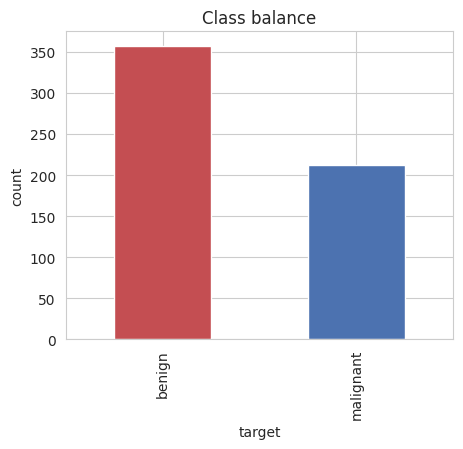

target
1    0.627
0    0.373
Name: proportion, dtype: float64


In [124]:
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().rename({0: 'malignant', 1: 'benign'}).plot(kind='bar', ax=ax, color=['#c44e52', '#4c72b0'])
ax.set_title("Class balance")
ax.set_ylabel("count")
plt.show()

print(y.value_counts(normalize=True).round(3))

**TODO (reflection):** Is this dataset balanced or imbalanced? Keep this in mind —
you'll come back to it in Section 8 when judging whether a model's accuracy number
alone tells the full story.

The dataset is mildly imbalanced because it contains more benign samples than malignant samples. There are 357 benign samples and 212 malignant samples, so benign cases make up about 62.7% of the dataset. Therefore, accuracy should not be considered alone when evaluating the model.

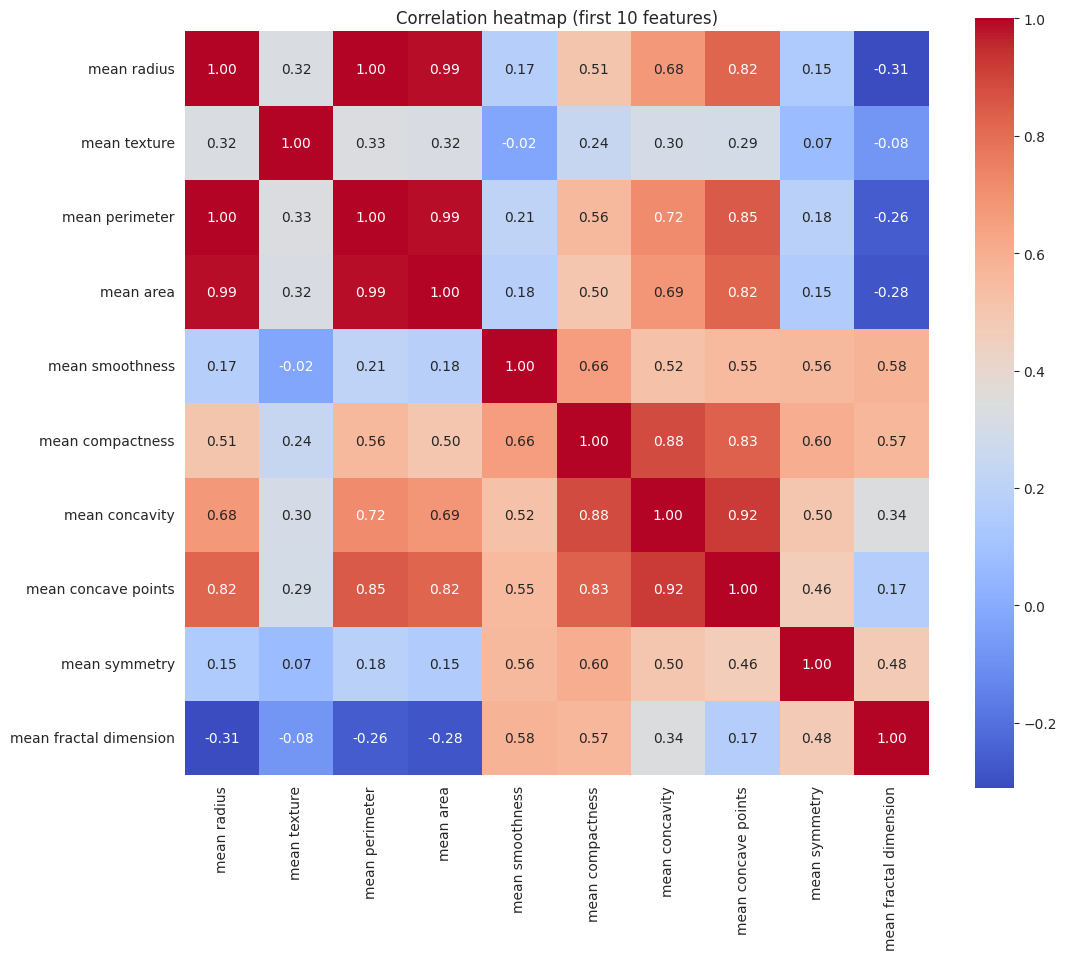

In [125]:
plt.figure(figsize=(12, 10))
corr = X.iloc[:, :10]  # first 10 features, full 30x30 is unreadable
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap (first 10 features)")
plt.show()

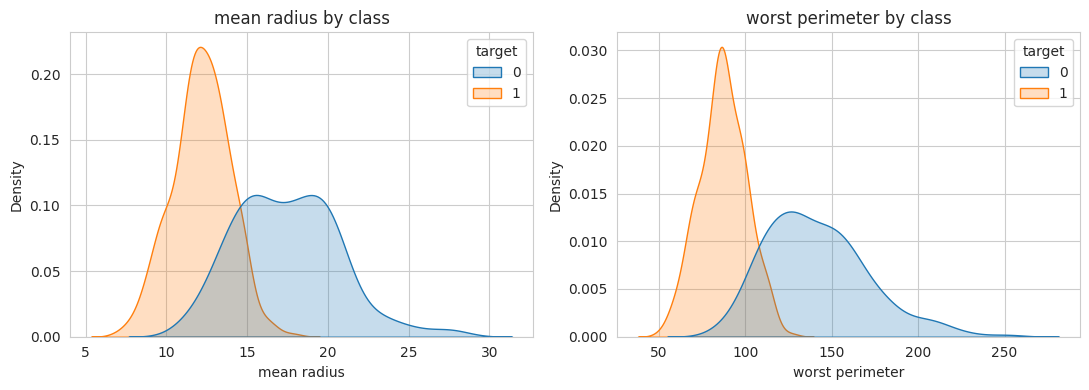

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ['mean radius', 'worst perimeter']):
    sns.kdeplot(data=X.assign(target=y), x=feat, hue='target', fill=True, ax=ax, common_norm=False)
    ax.set_title(f"{feat} by class")
plt.tight_layout()
plt.show()

---
## 3. Baseline Model

Train test split first, then fit a plain, default-parameter `DecisionTreeClassifier`.
Everything after this cell is measured against this baseline.

In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (455, 30)  Test: (114, 30)


In [128]:
baseline_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
print("Baseline accuracy:", round(baseline_acc, 4))
print("Baseline tree depth:", baseline_model.get_depth(), " | leaves:", baseline_model.get_n_leaves())
print()
print(classification_report(y_test, baseline_pred, target_names=data.target_names))

Baseline accuracy: 0.9123
Baseline tree depth: 7  | leaves: 19

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



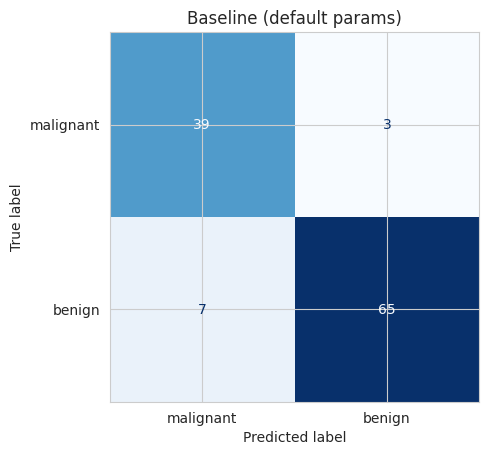

array([[39,  3],
       [ 7, 65]])

In [129]:
def plot_confusion(model, X_te, y_te, title):
    """Reusable confusion matrix plotter — you'll call this throughout the rest of the lab."""
    pred = model.predict(X_te)
    cm = confusion_matrix(y_te, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(title)
    plt.show()
    return cm

plot_confusion(baseline_model, X_test, y_test, "Baseline (default params)")

---
## 4. Gini vs Entropy

Same tree, same split, only the impurity measure changes.

In [130]:
# TODO: train one DecisionTreeClassifier per criterion in ['gini', 'entropy']
#       (same random_state=RANDOM_STATE, no other params changed).
#       For each, compute test-set accuracy and store it in a dict:
#           criterion_results = {'gini': <acc>, 'entropy': <acc>}
#       Print each criterion name, its accuracy, and the resulting tree depth
#       (hint: model.get_depth()).
#
# criterion_results = {}
# ...your code here...
criterion_results = {}

for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    criterion_results[criterion] = acc

    print(
        f"Criterion: {criterion}, "
        f"Accuracy: {round(acc, 4)}, "
        f"Depth: {model.get_depth()}"
    )

Criterion: gini, Accuracy: 0.9123, Depth: 7
Criterion: entropy, Accuracy: 0.9123, Depth: 6


Criterion: gini, Accuracy: 0.9123, Depth: 7
Criterion: entropy, Accuracy: 0.9123, Depth: 6


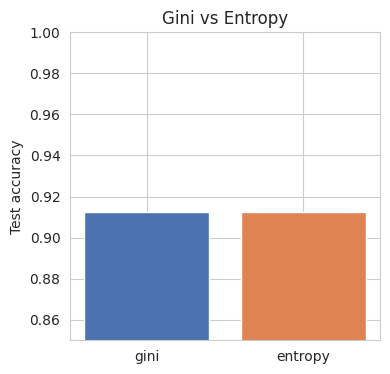

In [131]:
criterion_results = {}

for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    criterion_results[criterion] = acc
    print(f"Criterion: {criterion}, Accuracy: {round(acc, 4)}, Depth: {model.get_depth()}")

plt.figure(figsize=(4, 4))
plt.bar(criterion_results.keys(), criterion_results.values(), color=['#4c72b0', '#dd8452'])
plt.ylim(0.85, 1.0)
plt.ylabel("Test accuracy")
plt.title("Gini vs Entropy")
plt.show()

**TODO (reflection):** Gini and Entropy are both impurity measures but computed
differently (Gini: `1 - sum(p_i^2)`, Entropy: `-sum(p_i * log2(p_i))`). Did they produce
the same accuracy here? If so, does that mean they always pick the same splits — or just
that this dataset doesn't stress the difference? Write 2-3 sentences.

Gini and Entropy produced the same test accuracy of 91.23% on this dataset, but they produced trees with different depths. Gini produced a depth-7 tree while Entropy produced a depth-6 tree. This does not mean they always choose the same splits; it shows that their differences were not large enough to change the final test accuracy here.

---
## 5. Depth Exploration — the core overfitting curve

Sweep `max_depth` from 1 to 20 and track **train** and **test** accuracy separately.
This is the single most important plot in the lab.

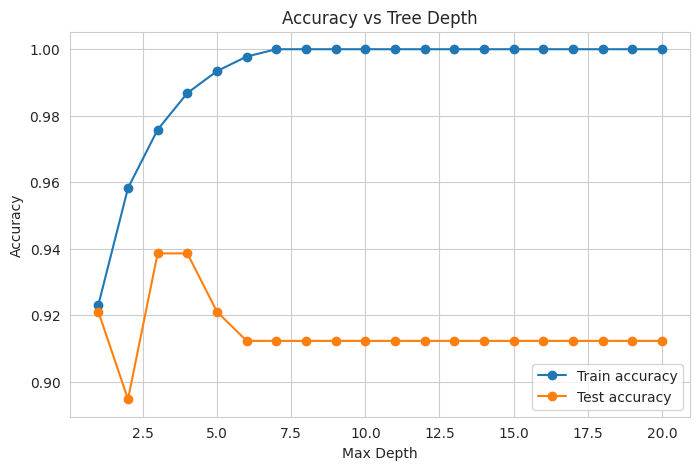

In [132]:
# TODO: for max_depth in range(1, 21):
#         - train a DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
#         - record TRAIN accuracy and TEST accuracy separately, in two lists
#       Use these exact names so later cells can find them:
#           depths = range(1, 21)
#           train_accs = [...]
#           test_accs  = [...]
#       Then plot both curves on the same figure (max_depth on x-axis, accuracy
#       on y-axis), with a legend distinguishing train vs test.
#
# depths = range(1, 21)
# train_accs, test_accs = [], []
# ...your code here...
depths = range(1, 21)

train_accs = []
test_accs = []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accs.append(
        accuracy_score(y_train, train_pred)
    )

    test_accs.append(
        accuracy_score(y_test, test_pred)
    )

plt.figure(figsize=(8, 5))

plt.plot(
    depths,
    train_accs,
    marker='o',
    label='Train accuracy'
)

plt.plot(
    depths,
    test_accs,
    marker='o',
    label='Test accuracy'
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

In [133]:
# TODO: using your test_accs list from above, find the max_depth value that
#       achieves the highest test accuracy. Store it as `best_depth_by_test`
#       (later cells use this exact name) and print it, along with the train
#       accuracy at that same depth.
#
# best_depth_by_test = ...
best_depth_by_test = depths[np.argmax(test_accs)]

print("Best depth:", best_depth_by_test)
print(
    "Test accuracy:",
    round(test_accs[best_depth_by_test - 1], 4)
)
print(
    "Train accuracy:",
    round(train_accs[best_depth_by_test - 1], 4)
)

Best depth: 3
Test accuracy: 0.9386
Train accuracy: 0.9758


---
## 6. Accuracy vs Depth, split by Criterion

Same sweep, but gini and entropy plotted separately — does the optimal depth shift?

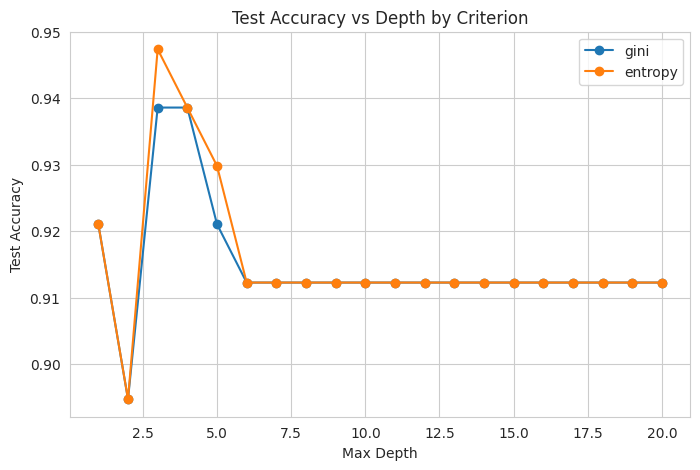

Best criterion: entropy
Best depth: 3
Best test accuracy: 0.9474


In [134]:
depth_criterion_results = {}

for criterion in ['gini', 'entropy']:

    results = []

    for d in depths:

        model = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=d,
            random_state=RANDOM_STATE
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        acc = accuracy_score(y_test, pred)

        results.append(acc)

    depth_criterion_results[criterion] = results

plt.figure(figsize=(8, 5))

for criterion in ['gini', 'entropy']:
    plt.plot(
        depths,
        depth_criterion_results[criterion],
        marker='o',
        label=criterion
    )

plt.xlabel("Max Depth")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Depth by Criterion")
plt.legend()
plt.grid(True)
plt.show()

best_c = None
best_d = None
best_score = -1

for criterion in depth_criterion_results:
    for i, score in enumerate(depth_criterion_results[criterion]):
        if score > best_score:
            best_score = score
            best_c = criterion
            best_d = depths[i]

print("Best criterion:", best_c)
print("Best depth:", best_d)
print("Best test accuracy:", round(best_score, 4))

---
## 7. Pruning — cost-complexity as an alternative to early stopping

`max_depth` stops the tree from growing past a certain point. Cost-complexity
pruning does the opposite: grow the full tree, then trim it back afterward
using `ccp_alpha`. Same goal (control overfitting), different mechanism.

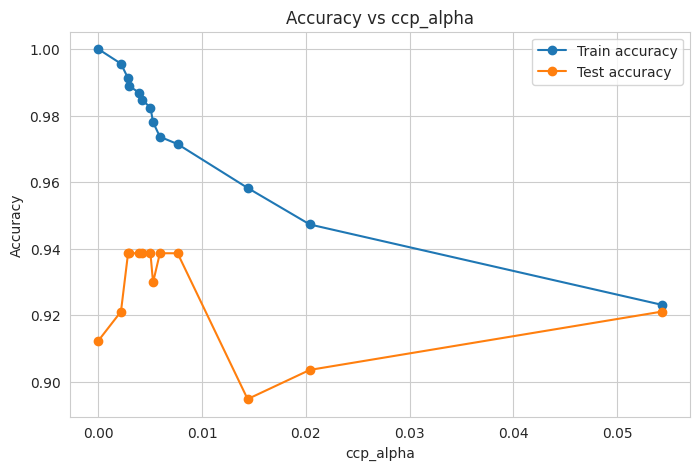

In [135]:
# TODO: cost-complexity pruning. Use
#           DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
#       to get `.ccp_alphas` (drop the last, trivial single-node alpha).
#       For each alpha, train a tree with that ccp_alpha and record BOTH train
#       and test accuracy. Plot both curves vs alpha.
#
# pruning_path = ...
# ccp_alphas = ...
# ...your code here...
pruning_path = DecisionTreeClassifier(
    random_state=RANDOM_STATE
).cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = pruning_path.ccp_alphas[:-1]

train_accs_pruning = []
test_accs_pruning = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    train_accs_pruning.append(
        accuracy_score(y_train, model.predict(X_train))
    )

    test_accs_pruning.append(
        accuracy_score(y_test, model.predict(X_test))
    )

plt.figure(figsize=(8, 5))

plt.plot(
    ccp_alphas,
    train_accs_pruning,
    marker='o',
    label='Train accuracy'
)

plt.plot(
    ccp_alphas,
    test_accs_pruning,
    marker='o',
    label='Test accuracy'
)

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs ccp_alpha")
plt.legend()
plt.grid(True)
plt.show()

**TODO (reflection):** `ccp_alpha` prunes a fully-grown tree after the fact,
instead of stopping it early like `max_depth` does. Compare this curve's shape
to the depth curve in Section 5 — same story, or different?

The ccp_alpha curve shows a similar pattern to the depth curve because reducing tree complexity can reduce overfitting. With little or no pruning, training accuracy is higher, while increasing ccp_alpha prunes more branches and reduces training accuracy. The test accuracy can improve at moderate pruning levels before decreasing when the tree becomes too simple.

---
## 8. Confusion Matrix Deep-Dive

Compare confusion matrices at a **shallow**, **near-optimal**, and **overly deep** tree
using the `plot_confusion()` function defined back in Section 3.

Shallow accuracy: 0.8947


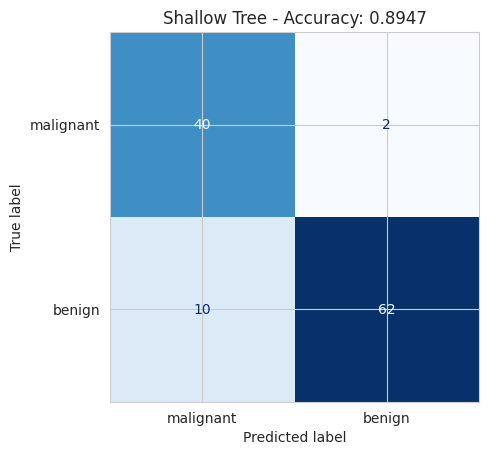

Near-optimal accuracy: 0.9386


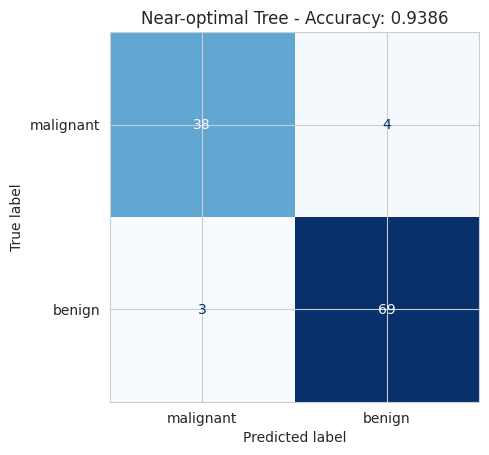

Overly deep accuracy: 0.9123


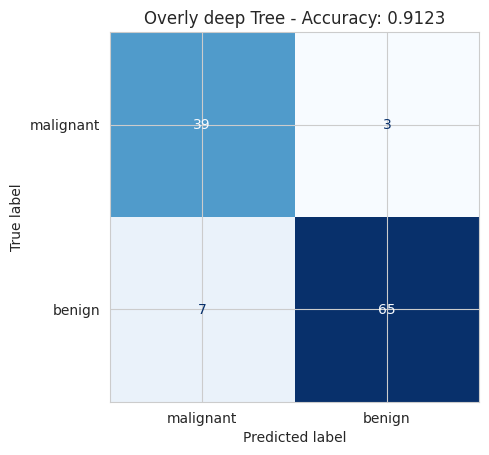

In [136]:
# TODO: train three models on X_train/y_train:
#         - a "shallow" tree with max_depth=2
#         - a "near-optimal" tree with max_depth=best_depth_by_test (from Section 5)
#         - an "overly deep" tree with max_depth=20
#       For each, compute test accuracy and call plot_confusion(model, X_test,
#       y_test, <a descriptive title including the accuracy>).
#
# shallow_model = ...
# best_model_depth_only = ...
# deep_model = ...
# ...your code here...
shallow_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=RANDOM_STATE
)

best_model_depth_only = DecisionTreeClassifier(
    max_depth=best_depth_by_test,
    random_state=RANDOM_STATE
)

deep_model = DecisionTreeClassifier(
    max_depth=20,
    random_state=RANDOM_STATE
)


models = [
    ("Shallow", shallow_model),
    ("Near-optimal", best_model_depth_only),
    ("Overly deep", deep_model)
]

for name, model in models:

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print(f"{name} accuracy: {acc:.4f}")

    plot_confusion(
        model,
        X_test,
        y_test,
        f"{name} Tree - Accuracy: {acc:.4f}"
    )

**TODO (reflection):** The accuracy numbers alone might look similar across these
three models. Do the confusion matrices tell a more interesting story than the
accuracy number does? Specifically: comparing the near-optimal tree to the
overly-deep one, which error type increases as depth grows past the sweet spot?
And separately — how does the shallow tree's error trade-off differ from both?

The confusion matrices show that the overly deep tree makes more malignant-to-benign errors as depth grows past the sweet spot, increasing from 3 to 7 missed malignant cases. The shallow tree makes fewer malignant-to-benign errors than the overly deep tree but has more benign-to-malignant errors, showing a different error trade-off. Therefore, the confusion matrix reveals differences that overall accuracy alone does not show.

---
## 9. Grid Search

Search jointly over criterion and depth parameters using
5-fold cross-validation on the training set.

In [137]:
# TODO: build a param_grid dict covering:
#           criterion: ['gini', 'entropy']
#           max_depth: [3, 4, 5, 6, 7, 8, None]
#
#       Then run GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
#       param_grid, cv=5, scoring='accuracy', n_jobs=-1) on X_train/y_train.
#       Print grid_search.best_params_ and grid_search.best_score_.

#       This grid has 2 criteria × 7 depths = 14 combinations. With `cv=5`, that means
#      `GridSearchCV` will fit 14 × 5 = 70 models total — which is why this cell takes
#       noticeably longer to run than any single `.fit()` call earlier in the lab.
#
# param_grid = {...}
# grid_search = ...
# ...your code here...
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, None]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV score:")
print(grid_search.best_score_)

Best parameters:
{'criterion': 'gini', 'max_depth': 4}
Best CV score:
0.9384615384615385


Baseline accuracy: 0.9123
Manual best accuracy: 0.9474
GridSearchCV test accuracy: 0.9386


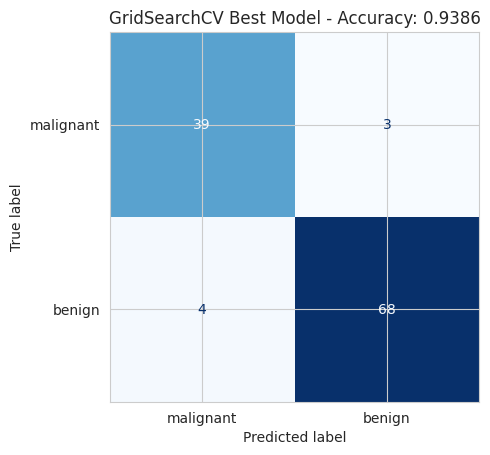

array([[39,  3],
       [ 4, 68]])

In [138]:
# TODO: pull grid_search.best_estimator_ into `best_model` (later cells use
#       this exact name). Compute its held-out test accuracy, print it next
#       to the Section 3 baseline accuracy and your manual best from Section 6,
#       and call plot_confusion() on it.
#
# best_model = ...
# ...your code here...
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

best_test_acc = accuracy_score(
    y_test,
    best_pred
)

print("Baseline accuracy:", round(baseline_acc, 4))

print(
    "Manual best accuracy:",
    round(best_score, 4)
)

print(
    "GridSearchCV test accuracy:",
    round(best_test_acc, 4)
)

plot_confusion(
    best_model,
    X_test,
    y_test,
    f"GridSearchCV Best Model - Accuracy: {best_test_acc:.4f}"
)

**TODO (reflection, no code):** Did GridSearchCV beat your manual exploration from
Sections 4-7? If not, why might that be, given cross-validation vs a single
train/test split?

GridSearchCV did not beat the manual exploration. The manual best model achieved a higher test accuracy of 94.74%, while GridSearchCV achieved 93.86%. However, the manual model was selected based on the same single test set, so its higher score may be due to that particular train/test split. GridSearchCV uses 5-fold cross-validation on the training data, making its model selection more reliable and less dependent on one split.

---
## 10. Bonus — Feature Importance & Tree Visualization

                 Feature  Importance
20          worst radius    0.733548
27  worst concave points    0.122028
11         texture error    0.045785
21         worst texture    0.032319
26       worst concavity    0.017161
7    mean concave points    0.013327
13            area error    0.012704
1           mean texture    0.011846
28        worst symmetry    0.011282
3              mean area    0.000000


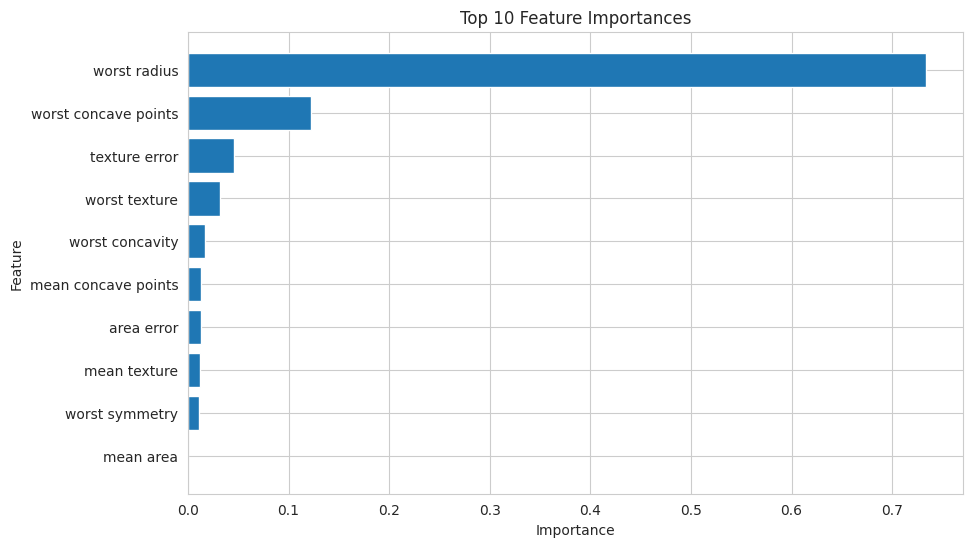

In [139]:
# TODO: using best_model.feature_importances_, build a DataFrame with columns
#       'Feature' and 'Importance', sort it descending, and bar-plot the top 10.
#
# importance = ...
# ...your code here...
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))


plt.figure(figsize=(10, 6))

plt.barh(
    importance.head(10)['Feature'][::-1],
    importance.head(10)['Importance'][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.show()

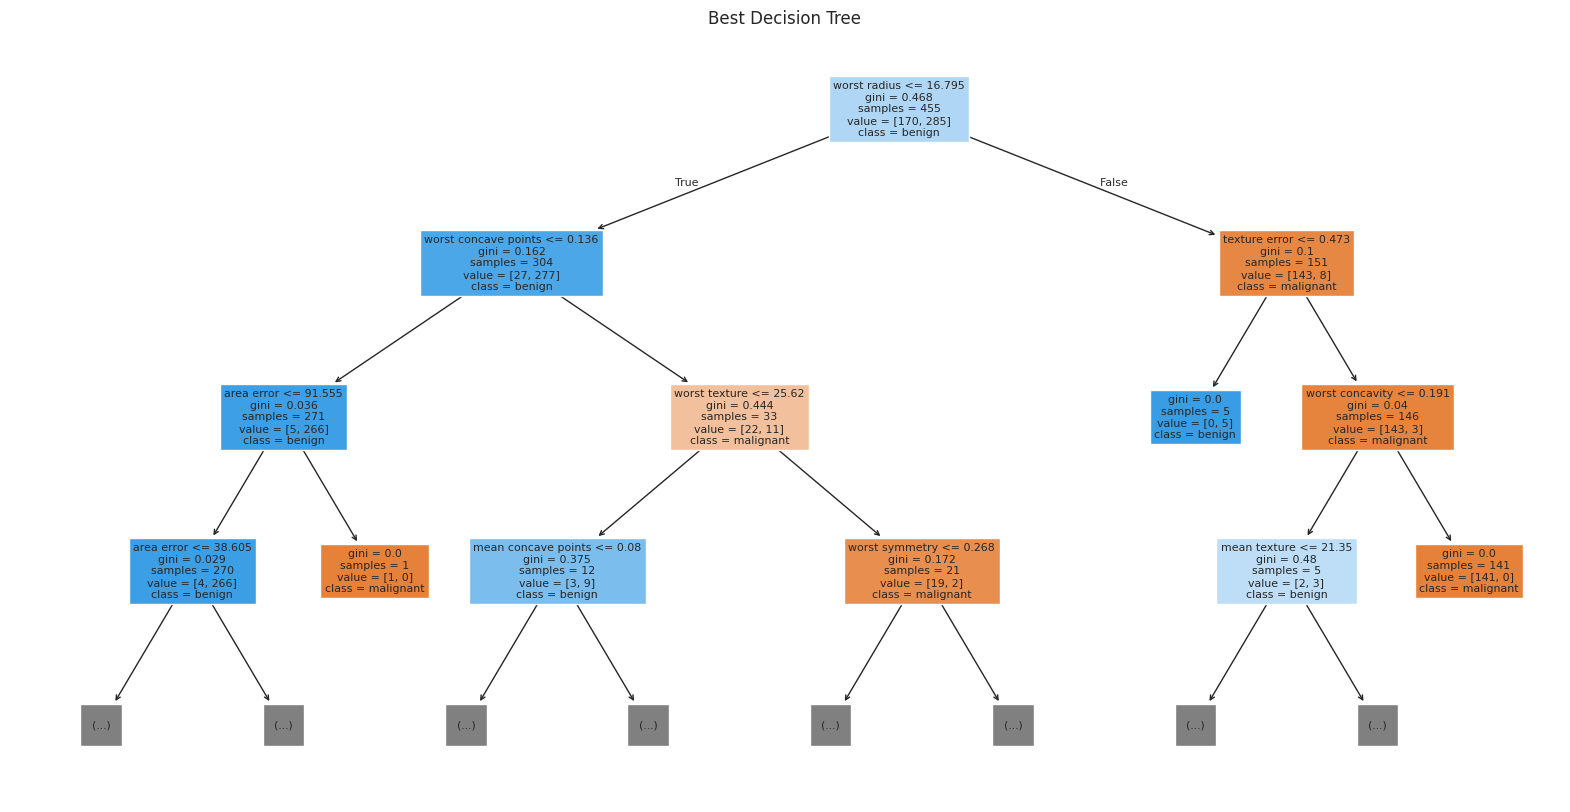

In [140]:
# TODO: use sklearn.tree.plot_tree() to visualize best_model. Pass
#       feature_names=X.columns, class_names=data.target_names, filled=True,
#       and max_depth=3 (the full tree is unreadable at this dataset's depth).
#
# ...your code here...
plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=3
)

plt.title("Best Decision Tree")
plt.show()

**TODO (reflection, no code):** Does the root-node split use one of the top-3 features
from the importance bar chart above? It should — explain in one sentence why
that's not a coincidence.


Yes, the root split uses one of the top-ranked features: worst radius is the root feature and also the most important feature. This is expected because the root split sees all training samples and therefore can contribute a large amount to the total impurity reduction.

---
## 11. Reflection / Write-up

Answer each of these in 2-4 sentences.

1. **Which hyperparameter had the biggest effect on overfitting — depth, criterion or ccp_alpha?** What made you pick that one?
    Tree depth had the biggest effect on overfitting. As depth increased, training accuracy reached 100%, while test accuracy peaked at depths 3 and 4 at about 93.86% and then dropped to about 91.23%. This growing gap between training and test accuracy is clear evidence of overfitting.

2. **Did Gini and Entropy ever meaningfully disagree** — on accuracy, depth, or which
   feature got picked at the root? Or did they behave almost identically throughout?
    Gini and Entropy behaved very similarly overall. Their default trees had the same test accuracy of 91.23%, although Gini produced depth 7 while Entropy produced depth 6. During the depth search, Entropy achieved a slightly better best test accuracy at depth 3, but the overall behavior of both criteria was similar.
   

3. **What would you tell someone who just maximizes test-set accuracy blindly**, without
   looking at confusion matrices or train/test gaps? Use something you saw in this lab
   as evidence.

    A single accuracy value does not show what types of mistakes the model makes. For example, the depth-3 tree incorrectly classified 4 malignant cases as benign, while the overly deep tree incorrectly classified 7 malignant cases as benign, even though its accuracy was still 91.23%. The train/test accuracy gap and confusion matrix therefore provide important information beyond accuracy alone.

4. **You controlled tree complexity three different ways in this lab** — `max_depth`
   (Section 5), `ccp_alpha` (Section 7), and `GridSearchCV`'s cross-validated search
   (Section 9).

   a) What's the key difference between how `max_depth` and `ccp_alpha` arrive at
      a simpler tree?


      max_depth controls complexity by stopping the tree from growing beyond a specified depth. In contrast, ccp_alpha allows the tree to grow first and then removes branches whose complexity is not worth the improvement they provide. Thus, max_depth is an early-stopping method, while ccp_alpha is a post-pruning method.

   b) Suppose your manual best from Section 6 scores higher on the test set than
      GridSearchCV's winner. Does that mean the manual pick is a genuinely better
      model? What does this tell you about comparing models this way?

      No, a higher test-set score for the manual model does not prove that it is genuinely better. The manual model was selected using the same test set, so its score may be affected by random variation in that particular split. GridSearchCV uses 5-fold cross-validation on the training data, which provides a more reliable basis for model selection.